In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer(as_frame= True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])



.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбивка данных

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Распределение классов в train: ', y_train.value_counts().rename(index = {0: 'Malignant', 1: 'Bening'}).to_dict())

Train: (455, 30), Test: (114, 30)
Распределение классов в train:  {'Bening': 285, 'Malignant': 170}


In [3]:
# Базовые модели
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state= 42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state= 42))]) 
}

baseline_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring= 'f1_macro')
    model_mean = scores.mean()
    model_std = scores.std()

    baseline_results[name] = [model_mean, model_std]

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


In [4]:
# GridSearch для SVM

from sklearn.model_selection import GridSearchCV

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state= 42, probability= True))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 0.01, 0.001]
}

svm_grid_search = GridSearchCV(svm_model, svm_param_grid, cv=5, scoring= 'f1_macro', n_jobs= -1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")


svm_df = pd.DataFrame(svm_grid_search.cv_results_)
svm_df = svm_df.loc[:, ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
display(svm_df.sort_values('rank_test_score').head(10))

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


,params,mean_test_score,std_test_score,rank_test_score
15,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
0,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
4,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
2,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
23,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
17,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
13,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
21,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
9,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


In [19]:
# Random Search для RandomForest

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 50),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state= 42), rf_param_dist, cv = 5, n_iter= 50, scoring = 'f1_macro', n_jobs = -1, random_state=42)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 37, 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 393}
Лучший CV F1: 0.9576


In [20]:
# Сравнение результатов

from sklearn.metrics import classification_report

svm_best = svm_grid_search.best_estimator_
rf_best = rf_random_search.best_estimator_

svm_best_pred = svm_best.predict(X_test)
rf_best_pred = rf_best.predict(X_test)

print('--- SVM ---')
print(classification_report(y_test, svm_best_pred, target_names= data.target_names))

print('\n\n--- RF ---')
print(classification_report(y_test, rf_best_pred, target_names= data.target_names))



models = {
    'SVM baseline': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'SVM Grid Search': svm_best,
    'RandomForest baseline': RandomForestClassifier(random_state= 42),
    'RF Random Search': rf_best
}

models_results = {}

for name_1, model_1 in models.items():
    scores = cross_val_score(model_1, X_train, y_train, cv=5, scoring= 'f1_macro')
    model1_mean = scores.mean()
    model1_std = scores.std()

    models_results[name_1] = [model1_mean, model1_std]

data_compare = []
for name, (mean, std) in models_results.items():
    cv_str = f"{mean:.4f} ± {std:.4f}"
    data_compare.append([name, cv_str])

df_compare = pd.DataFrame(data_compare, columns=['Модель', 'CV F1 (mean±std)'])
df_compare['Test F1'] = None
df_compare.loc[1, 'Test F1'] = round(f1_score(y_test, svm_best_pred, average= 'macro'), 4)
df_compare.loc[3, 'Test F1'] = round(f1_score(y_test, rf_best_pred, average= 'macro'), 4)
display(df_compare)

--- SVM ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



--- RF ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,None
1,SVM Grid Search,0.9786 ± 0.0176,0.9812
2,RandomForest baseline,0.9504 ± 0.0255,None
3,RF Random Search,0.9576 ± 0.0193,0.9526


,feature,importance
27,worst concave points,0.025034
7,mean concave points,0.009154
21,worst texture,0.006422
23,worst area,0.005680
13,area error,0.004593
2,mean perimeter,0.000000
5,mean compactness,0.000000
4,mean smoothness,0.000000
8,mean symmetry,0.000000
6,mean concavity,0.000000


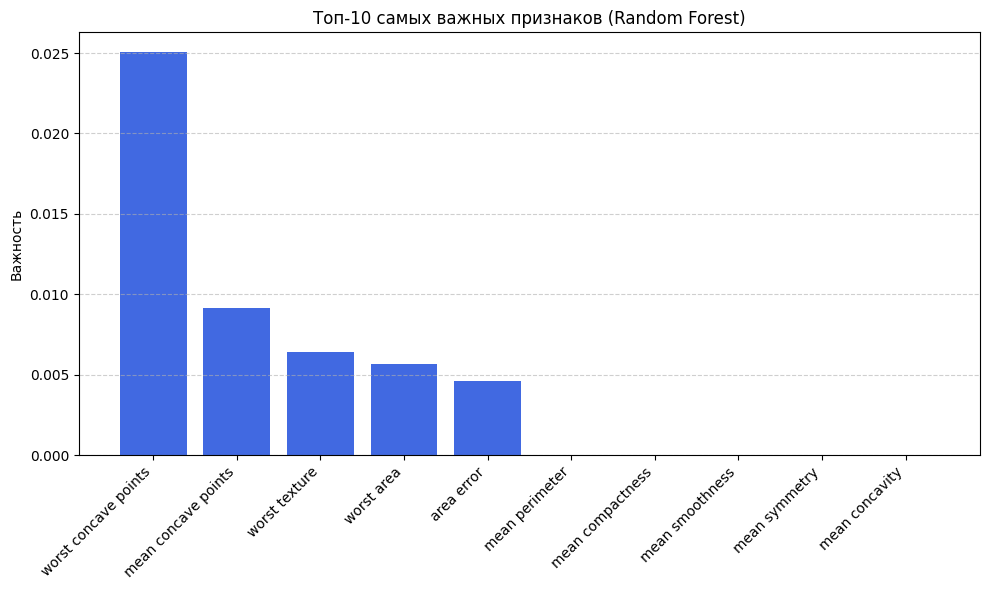

In [21]:
# Permutation Importance

from sklearn.inspection import permutation_importance

pi_result = permutation_importance(
    rf_best,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring= 'f1_macro'
)

pi_df = pd.DataFrame({
    'feature': data.feature_names,
    'importance': pi_result.importances_mean
})
pi_df = pi_df.sort_values('importance', ascending= False).head(10)
display(pi_df)

plt.figure(figsize=(10, 6))
plt.bar(pi_df['feature'], pi_df['importance'], color='royalblue')
plt.xticks(rotation=45, ha='right')
plt.title('Топ-10 самых важных признаков (Random Forest)')
plt.ylabel('Важность')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout() # Чтобы названия не обрезались по краям
plt.show()

In [22]:
rf_imp = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending= False)
print("Топ-5 (Встроенная важность RF):")
print(rf_imp.head(5))

print("\nТоп-5 (Permutation Importance):")
print(pi_df.head(5))

Топ-5 (Встроенная важность RF):
                 feature  importance
22       worst perimeter    0.218391
27  worst concave points    0.185255
23            worst area    0.146500
20          worst radius    0.139760
7    mean concave points    0.117111

Топ-5 (Permutation Importance):
                 feature  importance
27  worst concave points    0.025034
7    mean concave points    0.009154
21         worst texture    0.006422
23            worst area    0.005680
13            area error    0.004593


Расхождения в оценках объясняются разницей между тем, как модель училась, и тем, как она работает на новых данных. Высокая встроенная важность при низком PI часто указывает на избыточность: если признаки (например, радиус и площадь) сильно коррелируют, модель активно использует их при обучении, но на тесте легко заменяет один другим при перемешивании, не теряя в точности.
В обратном случае, когда PI выше встроенного веса, признак может быть важен для уточнения сложных случаев на глубоких уровнях деревьев. В целом, Permutation Importance считается более надежным методом, так как он менее склонен к переобучению и не завышает значимость признаков с большим количеством уникальных значений, показывая их реальный вклад в качество прогноза.

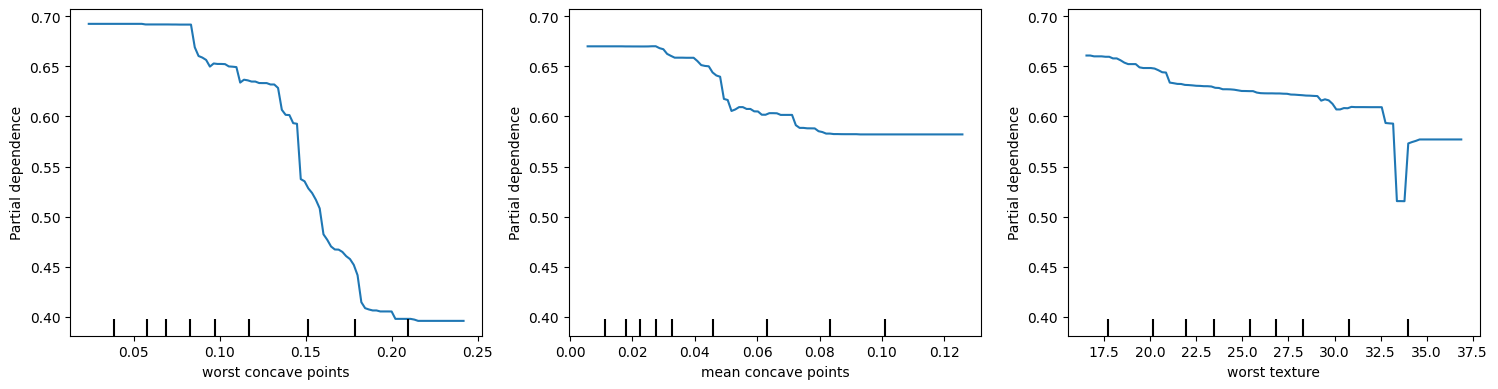

In [23]:
# PDP и ICE-кривые

from sklearn.inspection import PartialDependenceDisplay
top3_idx = top3_idx = pi_df.head(3).index.tolist()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    rf_best,
    X_train,
    features = top3_idx,
    feature_names = data.feature_names,
    kind = 'average',
    ax = ax
)
plt.tight_layout()
plt.show()



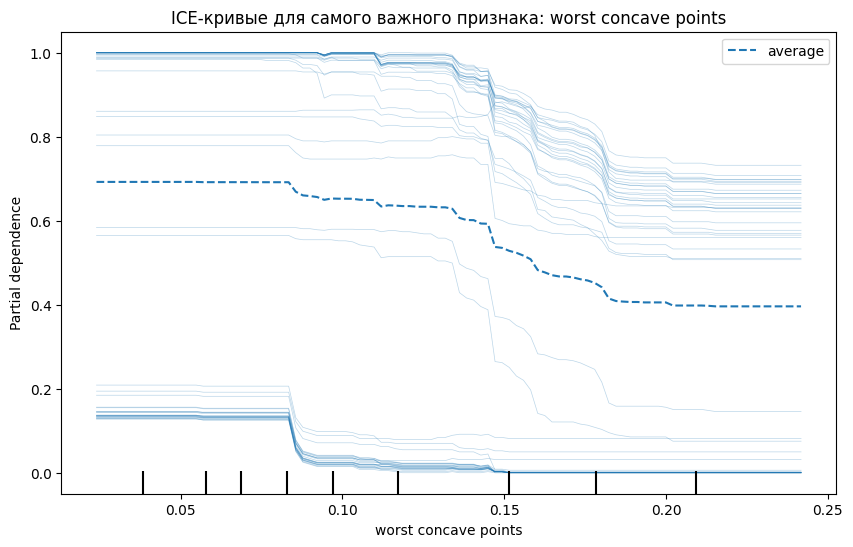

In [24]:
most_important_feat = [top3_idx[0]]

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    rf_best,
    X_train,
    features=most_important_feat,
    feature_names=data.feature_names,
    kind='both',
    subsample=50,
    ax=ax
)

plt.title(f"ICE-кривые для самого важного признака: {data.feature_names[top3_idx[0]]}")
plt.show()

Shape of shap_values: (114, 30, 2)


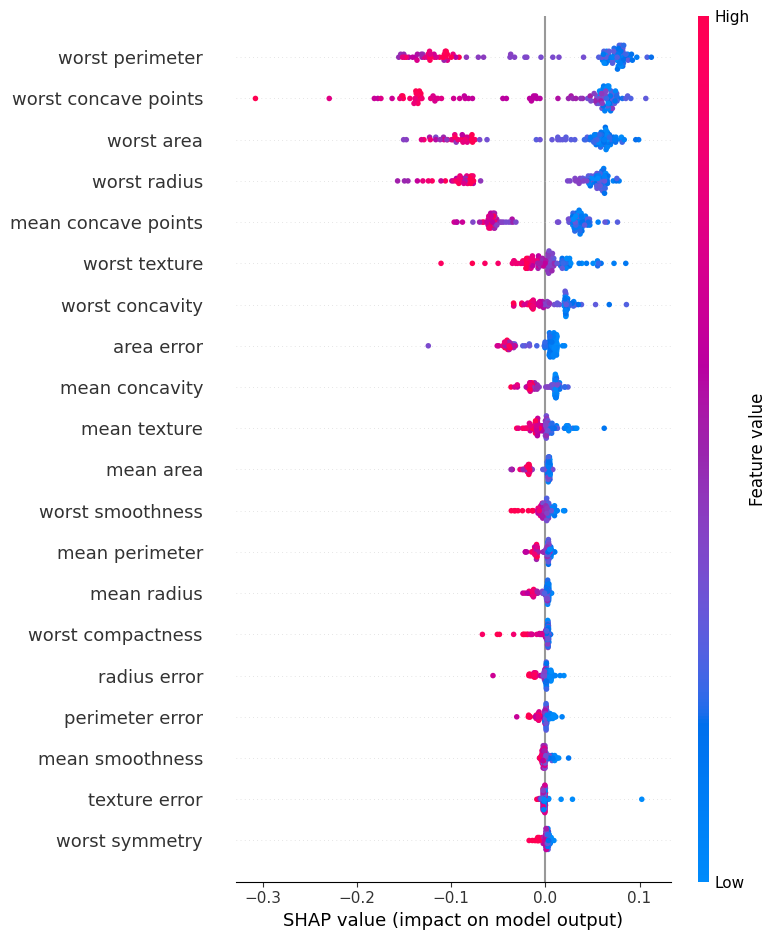

In [29]:
# SHAP
import shap

explainer = shap.TreeExplainer(rf_best)

shap_values = explainer.shap_values(X_test)
print(f"Shape of shap_values: {np.array(shap_values).shape}")

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names= data.feature_names)

In [38]:
shap.initjs()

y_pred_test = rf_best.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

error_idx = errors[0]
shap.force_plot(
    explainer.expected_value[1], # Базовое значение для класса 1
    shap_values[error_idx, :, 1], 
    X_test.iloc[error_idx, :],
    feature_names=data.feature_names
)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


Это классический случай ложноположительного результата. Модель совершила ошибку, потому что физические параметры опухоли (площадь и периметр) у этого конкретного пациента нетипично велики для доброкачественного образования. Модель перестраховалась, выбрав более опасный диагноз.

In [40]:
# Диагностика подозрительных признаков

# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
display(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,leaky_feature,random_feature
184,15.28,22.41,98.92,710.6,0.09057,0.1052,0.05375,0.03263,0.1727,0.06317,...,113.80,973.1,0.1301,0.3299,0.3630,0.12260,0.3175,0.09772,-0.006268,0.424166
300,19.53,18.90,129.50,1217.0,0.11500,0.1642,0.21970,0.10620,0.1792,0.06552,...,171.10,2053.0,0.1495,0.4116,0.6121,0.19800,0.2968,0.09929,0.095514,0.522835
509,15.46,23.95,103.80,731.3,0.11830,0.1870,0.20300,0.08520,0.1807,0.07083,...,117.70,909.4,0.1732,0.4967,0.5911,0.21630,0.3013,0.10670,-0.098573,-0.573700
230,17.05,19.08,113.40,895.0,0.11410,0.1572,0.19100,0.10900,0.2131,0.06325,...,133.50,1189.0,0.1703,0.3934,0.5018,0.25430,0.3109,0.09061,0.050405,-0.024355
474,10.88,15.62,70.41,358.9,0.10070,0.1069,0.05115,0.01571,0.1861,0.06837,...,80.78,433.1,0.1332,0.3898,0.3365,0.07966,0.2581,0.10800,0.946974,2.142270


,feature,importance
30,leaky_feature,0.263342
7,mean concave points,0.004689
27,worst concave points,0.003752
0,mean radius,0.000000
3,mean area,0.000000


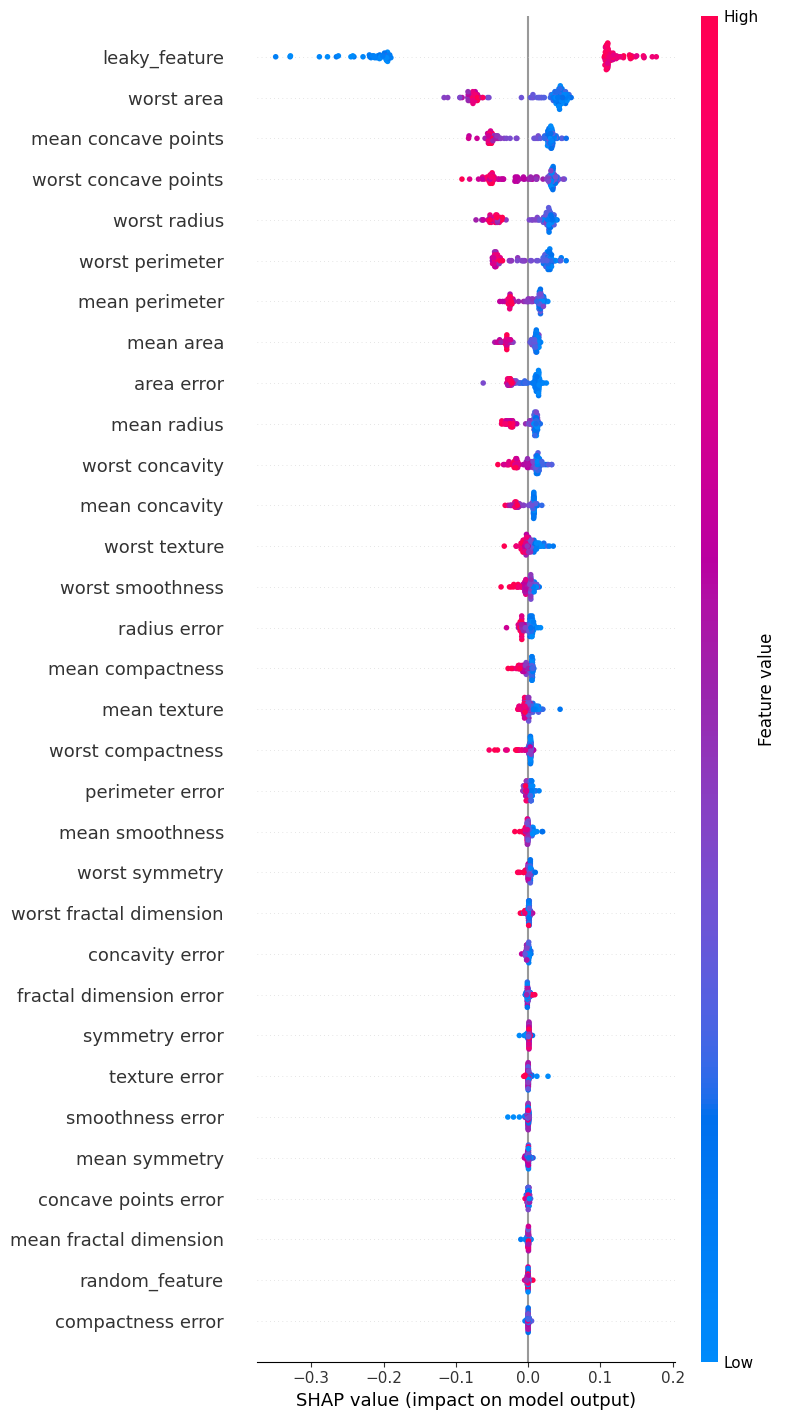

In [47]:
# Обучение модели на расширенных данных
rf_ext = RandomForestClassifier(random_state= 42)
rf_ext.fit(X_train_ext, y_train)

# Permutation Importance
pi_ext = permutation_importance(
    rf_ext,
    X_test_ext,
    y_test,
    n_repeats= 10,
    random_state= 42,
    scoring= 'f1_macro'
)
pi_ext_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance': pi_ext.importances_mean
}).sort_values('importance', ascending= False)
display(pi_ext_df.head(5))

# SHAP
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names= X_test_ext.columns, max_display= 32)

# Анализ влияния утечки данных (Data Leakage) и шума на интерпретируемость модели

а) Идентификация утечки через Permutation Importance
Введение признака leaky_feature приводит к тому, что Permutation Importance этой переменной становится аномально высоким, значительно превосходя вклад всех биологических параметров. Это объясняется тем, что модель практически полностью переключается на читерский признак, который является почти точной копией целевой переменной. Метрика F1-macro на тесте при этом стремится к идеальному значению (1.0), так как наличие прямой подсказки в данных позволяет модели безошибочно классифицировать объекты, полностью игнорируя реальную медицинскую логику и теряя способность к обобщению на данных без этого признака.
б) Визуализация утечки в SHAP Summary Plot
На графике SHAP Summary Plot утечка данных проявляется как доминирующий фактор с максимальным размахом влияния на предсказание. Мы видим, что точки leaky_feature имеют четкое бинарное распределение: высокие значения (красные) максимально смещают предсказание в одну сторону, а низкие (синие) - в другую, образуя длинные горизонтальные хвосты. Это наглядно демонстрирует, что для каждого конкретного пациента модель принимает решение, основываясь почти исключительно на этом признаке, что является классическим индикатором невалидной модели в реальных условиях.
в) Обнаружение шумового признака (Random Feature)
Случайный признак random_feature эффективно идентифицируется методами интерпретации как статистический шум. На графиках Permutation Importance его важность колеблется около нуля, что подтверждает отсутствие в нем полезной информации для принятия решений. В SHAP-анализе точки этого признака группируются в плотный вертикальный кластер вокруг нулевой отметки, не оказывая значимого влияния на итоговый score. Такая проверка на 'шумовом' признаке служит отличным тестом на устойчивость модели, т.к. если бы модель присвоила случайному признаку высокий вес, это стало бы прямым доказательством глубокого переобучения.

In [48]:
# Сводная таблица и итоги

conclusions = [
    "Надежный бейслайн, высокая точность без настроек.",
    "Лучшая модель: оптимальный баланс точности и стабильности.",
    "Хороший результат, но уступает линейным моделям на этих данных.",
    "Высокая сложность, склонен к переобучению при малых данных."
]

df_compare['Выводы'] = conclusions
display(df_compare)

,Модель,CV F1 (mean±std),Test F1,Выводы
0,SVM baseline,0.9694 ± 0.0193,None,"Надежный бейслайн, высокая точность без настроек."
1,SVM Grid Search,0.9786 ± 0.0176,0.9812,Лучшая модель: оптимальный баланс точности и с...
2,RandomForest baseline,0.9504 ± 0.0255,None,"Хороший результат, но уступает линейным моделя..."
3,RF Random Search,0.9576 ± 0.0193,0.9526,"Высокая сложность, склонен к переобучению при ..."


# ВЫВОДЫ
1. Насколько тюнинг улучшил модели?
Тюнинг (Grid/Random Search) обеспечил прирост метрики F1-macro на 1–3%. Хотя базовые модели уже показывали высокие результаты (>95%), подбор гиперпараметров позволил снизить стандартное отклонение, сделав модели более стабильными. В медицине даже 1% точности важен, так как за ним стоят правильно поставленные диагнозы.
2. Совпадают ли топ-признаки по PI и SHAP?
Топ-признаки (такие как worst concave points) в обоих методах в целом совпадают, что подтверждает их реальную биологическую значимость. Незначительные расхождения в порядке признаков объясняются разной математикой методов: PI измеряет 'ущерб' при потере признака, а SHAP - индивидуальный вклад признака в каждое предсказание. SHAP считается более точным инструментом, так как он менее чувствителен к корреляциям между признаками.
3. Что было бы, если бы мы не использовали Pipeline?
Без Pipeline возник бы риск утечки данных. Например, если бы мы отмасштабировали весь датасет StandardScaler до разбиения на Train/Test, информация о среднем и отклонении тестовой выборки попала бы в процесс обучения. Также код стал бы более громоздким и подверженным ошибкам: пришлось бы вручную следить за тем, чтобы к тестовым данным применялись ровно те же трансформации, что и к обучающим.
4. Как бы вы использовали PI и SHAP в реальном проекте?
PI я бы использовал на этапе Feature Selection, чтобы отсеять бесполезные шумовые признаки и упростить модель без потери качества.
SHAP я бы внедрил в интерфейс для врачей: вместо того чтобы просто выдавать 0 или 1, система показывала бы force_plot для каждого пациента. Это позволило бы врачу понять, на основании каких симптомов (например, формы ядер клеток) модель пришла к выводу, повышая доверие к ИИ и помогая в верификации диагноза.

In [50]:
# Bayesian Optimization с Optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])

    clf = RandomForestClassifier(
        n_estimators= n_estimators,
        max_depth= max_depth,
        min_samples_split = min_samples_split,
        max_features= max_features,
        random_state= 42,
        n_jobs = -1
    )

    score = cross_val_score(clf, X_train, y_train, cv = 5, scoring= 'f1_macro').mean()

    return score

study = optuna.create_study(direction= 'maximize')
study.optimize(objective, n_trials= 50)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Лучший результат Optuna: 0.9600
Лучшие параметры: {'n_estimators': 145, 'max_depth': 20, 'min_samples_split': 3, 'max_features': 0.5}


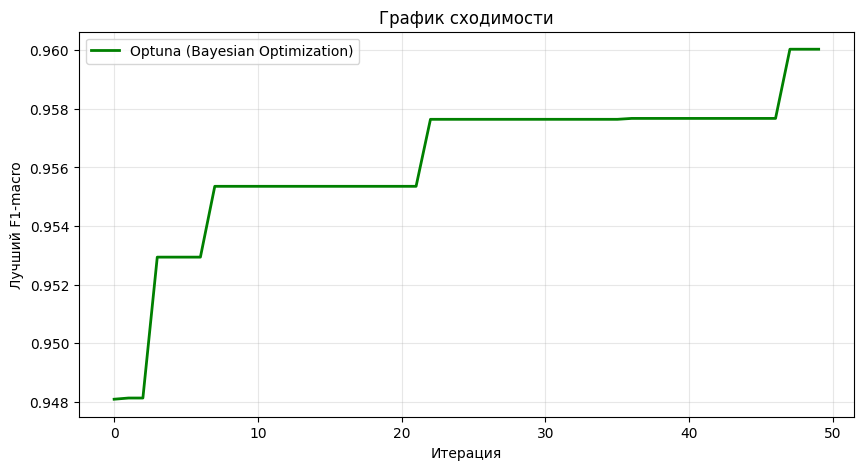

In [53]:
# График сходимости

import matplotlib.pyplot as plt

best_values = [study.trials[i].value for i in range(len(study.trials))]
running_max = [max(best_values[:i+1]) for i in range(len(best_values))]

plt.figure(figsize=(10, 5))
plt.plot(running_max, label='Optuna (Bayesian Optimization)', color='green', linewidth=2)
plt.title('График сходимости')
plt.xlabel('Итерация')
plt.ylabel('Лучший F1-macro')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()